In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

print("### Задача 1, повний перебір ###")
diffs = []
for i in range(1, 7):
    for j in range(1, 7):
        diffs.append(i - j)

mean_bf = np.mean(diffs)
var_bf = np.var(diffs)
p_zero_bf = diffs.count(0) / len(diffs)

print("Теоретично: E = 0, Var = 35 / 6, P(E = 0) = 1 / 6")
print(f"Перебір: E = {mean_bf}, Var = {var_bf:.4f}, P(E = 0) = {p_zero_bf:.4f} \n")

print("### ЗАДАЧА 1, симуляції ###")
for n in [100, 1000, 10000]:
    dice1 = np.random.randint(1, 7, n)
    dice2 = np.random.randint(1, 7, n)
    sim_diffs = dice1 - dice2

    sim_mean = np.mean(sim_diffs)
    sim_var = np.var(sim_diffs)
    sim_p_zero = np.sum(sim_diffs == 0) / n

    print(f"n={n:<5}: E = {sim_mean:>7.4f}, Var = {sim_var:>7.4f}, P(E=0) = {sim_p_zero:>7.4f}")

### Задача 1, повний перебір ###
Теоретично: E = 0, Var = 35 / 6, P(E = 0) = 1 / 6
Перебір: E = 0.0, Var = 5.8333, P(E = 0) = 0.1667 

### ЗАДАЧА 1, симуляції ###
n=100  : E = -0.3200, Var =  3.8976, P(E=0) =  0.2800
n=1000 : E =  0.1650, Var =  5.3438, P(E=0) =  0.1810
n=10000: E =  0.0189, Var =  5.6997, P(E=0) =  0.1700


In [29]:
### ЗАДАЧА 2, теоретичні функції ###

def f(t):
    if 0 < t <= 3:
        return 3 / 11
    elif 3 < t < 5:
        return 1 / 11
    else:
        return 0

def F_theor(t):
    if t <= 0:
        return 0
    elif t <= 3:
        return 3 * t / 11
    elif t <= 5:
        return (t + 6) / 11
    else:
        return 1

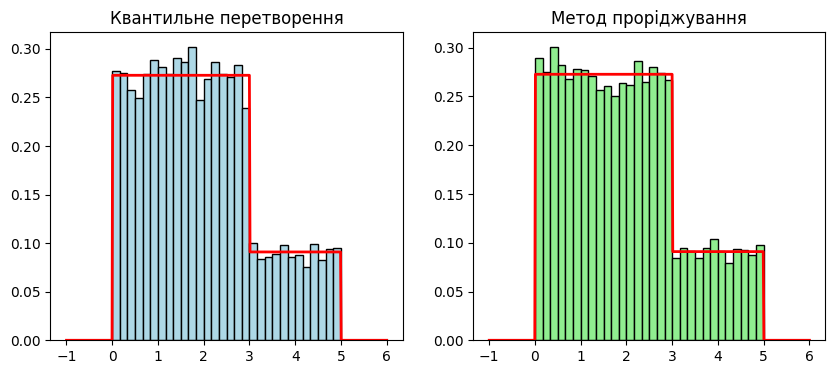

In [30]:
### 1. Квантильне перетворення ###
def get_inverse_samples(n):
    U = np.random.uniform(0, 1, n)
    samples = []
    for u in U:
        if u <= 9 / 11:
            samples.append(11 * u / 3)
        else:
            samples.append(11 * u - 6)
    return np.array(samples)

### 2. Метод проріджування ###
def get_rejection_samples(n):
    samples = []
    while len(samples) < n:
        y = np.random.uniform(0, 5)
        u = np.random.uniform(0, 1)

        if u <= f(y) / (3 / 11):
            samples.append(y)
    return np.array(samples)

### дані для гістограм ###
n_hist = 10000
samp_inv = get_inverse_samples(n_hist)
samp_rej = get_rejection_samples(n_hist)

### Створення графіків ###
t_vals = np.linspace(-1, 6, 500)
f_vals = [f(t) for t in t_vals]

plt.figure(figsize=(10, 4))

### Графік 1 ###
plt.subplot(1, 2, 1)
plt.hist(samp_inv, bins = 30, density = True, color = 'lightblue', edgecolor = 'black')
plt.plot(t_vals, f_vals, 'r-', lw = 2)
plt.title("Квантильне перетворення")

### Графік 2 ###
plt.subplot(1, 2, 2)
plt.hist(samp_rej, bins = 30, density = True, color = 'lightgreen', edgecolor = 'black')
plt.plot(t_vals, f_vals, 'r-', lw = 2)
plt.title("Метод проріджування")

plt.show()

In [31]:
print("ЗАДАЧА 2: Квантильний метод")
for n in [100, 1000, 10000]:
    s = get_inverse_samples(n)
    print(f"n = {n:<5}: Наближене E = {np.mean(s):.4f}, Var = {np.var(s):.4f}")

print("\nТеоретично: E = 1.9545, Var = 1.6040")

print("\nЗАДАЧА 2: Чисельне інтегрування")
### Математичне сподівання ###
E_num, _ = quad(lambda t: t * f(t), 0, 5)

### Дисперсія ###
E2_num, _ = quad(lambda t: (t ** 2) * f(t), 0, 5)
Var_num = E2_num - E_num ** 2

print(f"E   = {E_num:.5f}")
print(f"Var = {Var_num:.5f}")

### Функція розподілу чисельно ###
def F_num(t):
    res, _ = quad(f, 0, max(0, min(t, 5)))
    return res

print("\nПеревірка F(t):")
for t_test in [1.5, 4]:
    print(f"t = {t_test}: F(t) = {F_num(t_test):.4f} | теорія = {F_theor(t_test):.4f}")

ЗАДАЧА 2: Квантильний метод
n = 100  : Наближене E = 1.7144, Var = 1.1909
n = 1000 : Наближене E = 1.9612, Var = 1.5596
n = 10000: Наближене E = 1.9514, Var = 1.5895

Теоретично: E = 1.9545, Var = 1.6040

ЗАДАЧА 2: Чисельне інтегрування
E   = 1.95455
Var = 1.60399

Перевірка F(t):
t = 1.5: F(t) = 0.4091 | теорія = 0.4091
t = 4: F(t) = 0.9091 | теорія = 0.9091
